In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
#Load LSTM data
PROCESSED_DIR = Path("/content/drive/MyDrive/data/processed")

data = np.load(PROCESSED_DIR / "auslan_lstm_processed.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print("Files: ",data.files)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Files:  ['X_train', 'y_train', 'X_test', 'y_test']
X_train: (1710, 57, 22)
X_test : (855, 57, 22)
y_train: (1710,)
y_test : (855,)


In [4]:
#Build 1 Layer Architecture LSTM
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(57, 22)),

    tf.keras.layers.LSTM(128),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(95, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 95)             │        12,255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,567 (349.87 KB)

 Trainable params: 89,567 (349.87 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Train LSTM model
#Reserve 10% of training data for validation

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.0312 - loss: 4.4564 - val_accuracy: 0.0643 - val_loss: 4.1690
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.0864 - loss: 3.8212 - val_accuracy: 0.1111 - val_loss: 3.4452
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.1709 - loss: 3.2226 - val_accuracy: 0.1462 - val_loss: 3.0600
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.2112 - loss: 2.8779 - val_accuracy: 0.1988 - val_loss: 2.6472
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.2534 - loss: 2.6090 - val_accuracy: 0.2924 - val_loss: 2.4941
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.2703 - loss: 2.6003 - val_accuracy: 0.2281 - val_loss: 2.4888
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3125 - loss: 2.3251 - val_accuracy: 0.3333 - val_loss: 2.2219
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.3665 - loss: 2.1347 - val_accuracy: 0.3977 - 

In [6]:
#Evaluate LSTM
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)
label_mapping = pd.read_csv(PROCESSED_DIR / "label_mapping.csv")

target_names = label_mapping.sort_values("class_id")["sign"].tolist()

y_prob = model.predict(X_test)

y_pred = np.argmax(y_prob, axis=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4
))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7251 - loss: 0.9143
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
Test Loss: 0.9143
Test Accuracy: 0.7251
                precision    recall  f1-score   support

           God     0.8750    0.7778    0.8235         9
             I     0.6667    0.4444    0.5333         9
        Norway     0.6667    0.6667    0.6667         9
         alive     0.7778    0.7778    0.7778         9
           all     0.7500    1.0000    0.8571         9
        answer     0.8333    0.5556    0.6667         9
           boy     0.2500    0.3333    0.2857         9
      building     0.6667    0.4444    0.5333         9
           buy     1.0000    0.5556    0.7143         9
  change_mind_     0.4000    0.8889    0.5517         9
          cold     1.0000    1.0000    1.0000         9
          come     0.6250    0.5556    0.5882         9
  computer_PC_     1.0000    1.0000    1.0000         9
          cost     0.9000    1.0000    0.9474         9
     

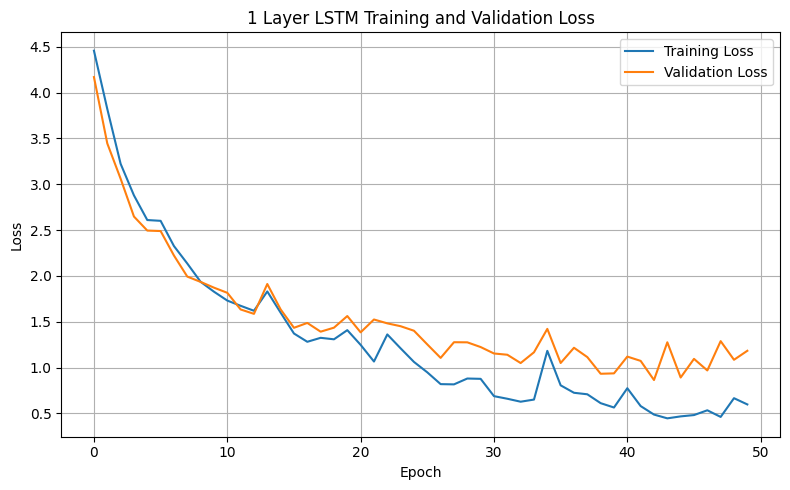

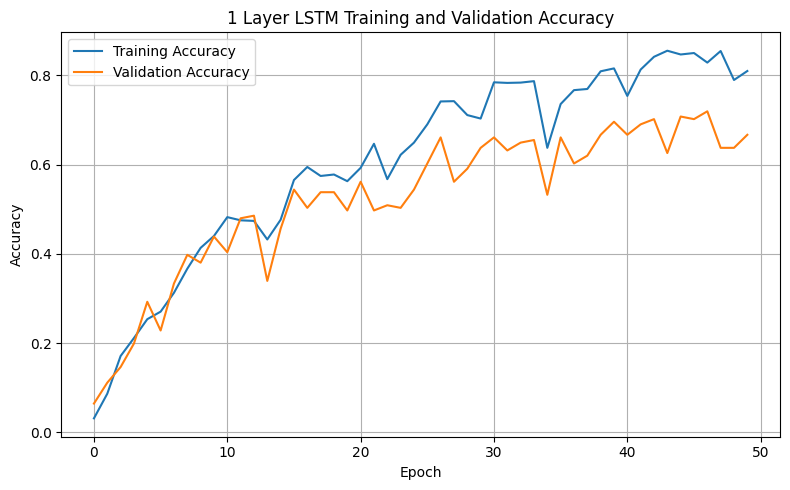

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1 Layer LSTM Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1 Layer LSTM Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

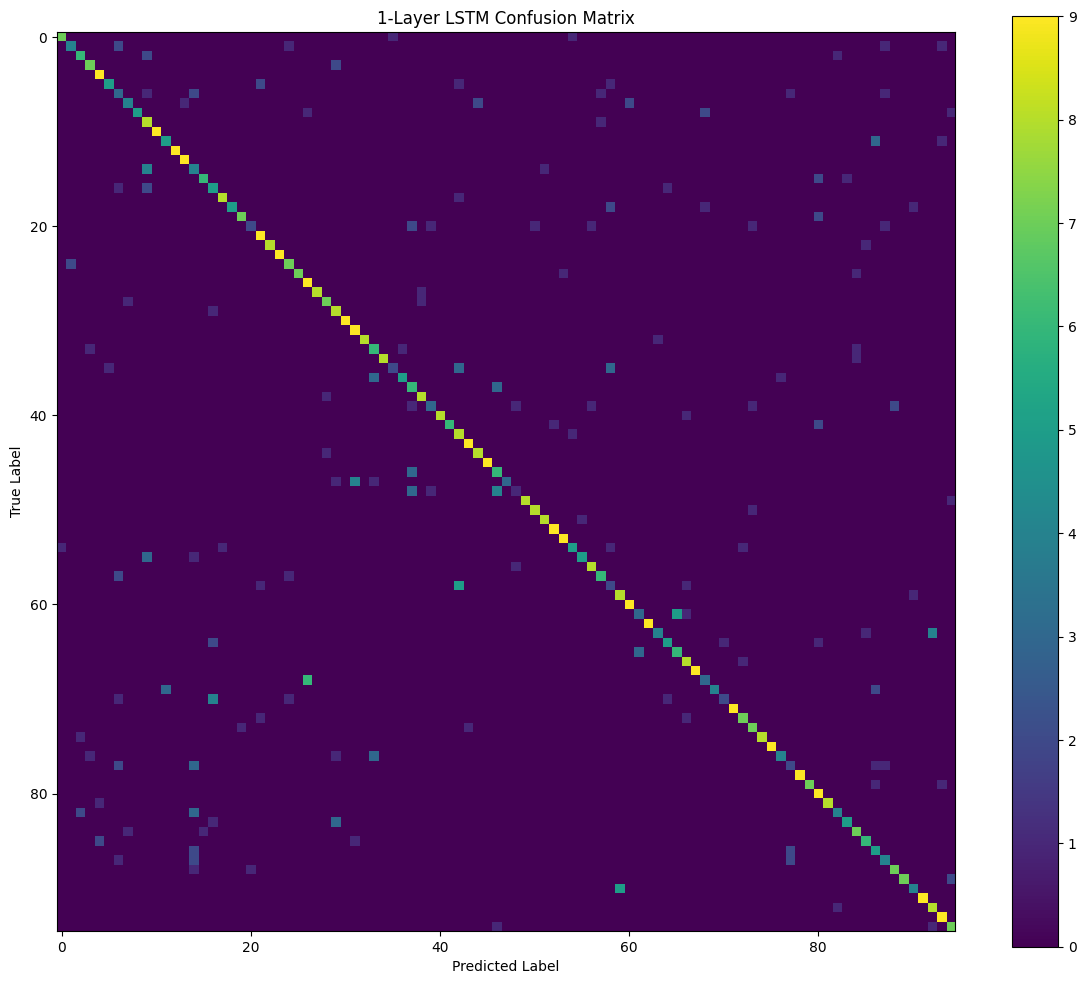

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("1-Layer LSTM Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [9]:
#Build 2 Layer Architecture LSTM

model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(57, 22)),

    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(95, activation="softmax")
])

model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 57, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 57, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 95)             │         6,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,895 (519.12 KB)

 Trainable params: 132,895 (519.12 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

history = model_2.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.0409 - loss: 4.4530 - val_accuracy: 0.0526 - val_loss: 4.1897
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.0884 - loss: 3.9286 - val_accuracy: 0.0643 - val_loss: 3.6536
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.1352 - loss: 3.4655 - val_accuracy: 0.1404 - val_loss: 3.3069
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.1832 - loss: 3.1068 - val_accuracy: 0.1930 - val_loss: 2.8438
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.2248 - loss: 2.8167 - val_accuracy: 0.1520 - val_loss: 2.7423
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.2352 - loss: 2.6878 - val_accuracy: 0.1228 - val_loss: 2.7045
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.2677 - loss: 2.5551 - val_accuracy: 0.1930 - val_loss: 2.6650
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.3021 - loss: 2.3711 - val_accuracy: 0.2

In [11]:
test_loss, test_accuracy = model_2.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_prob = model_2.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4
))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7556 - loss: 0.7803
Test Loss: 0.7803
Test Accuracy: 0.7556
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
                precision    recall  f1-score   support

           God     0.9000    1.0000    0.9474         9
             I     0.8750    0.7778    0.8235         9
        Norway     0.4000    0.2222    0.2857         9
         alive     0.7273    0.8889    0.8000         9
           all     0.7500    1.0000    0.8571         9
        answer     0.6667    0.6667    0.6667         9
           boy     0.4286    0.6667    0.5217         9
      building     0.8889    0.8889    0.8889         9
           buy     1.0000    0.5556    0.7143         9
  change_mind_     0.5294    1.0000    0.6923         9
          cold     1.0000    1.0000    1.0000         9
          come     1.0000    0.4444    0.6154         9
  computer_PC_     1.0000    1.0000    1.0000         9
          cost     1.0000    1.0000    1.0000         9
     

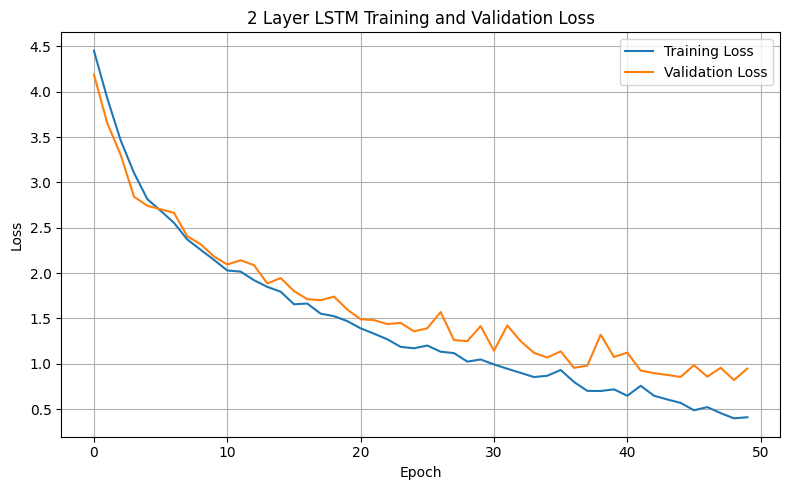

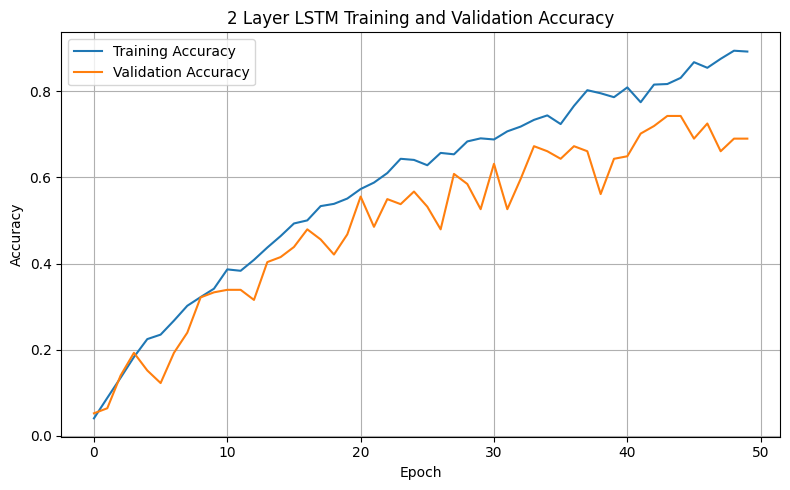

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2 Layer LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("2 Layer LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

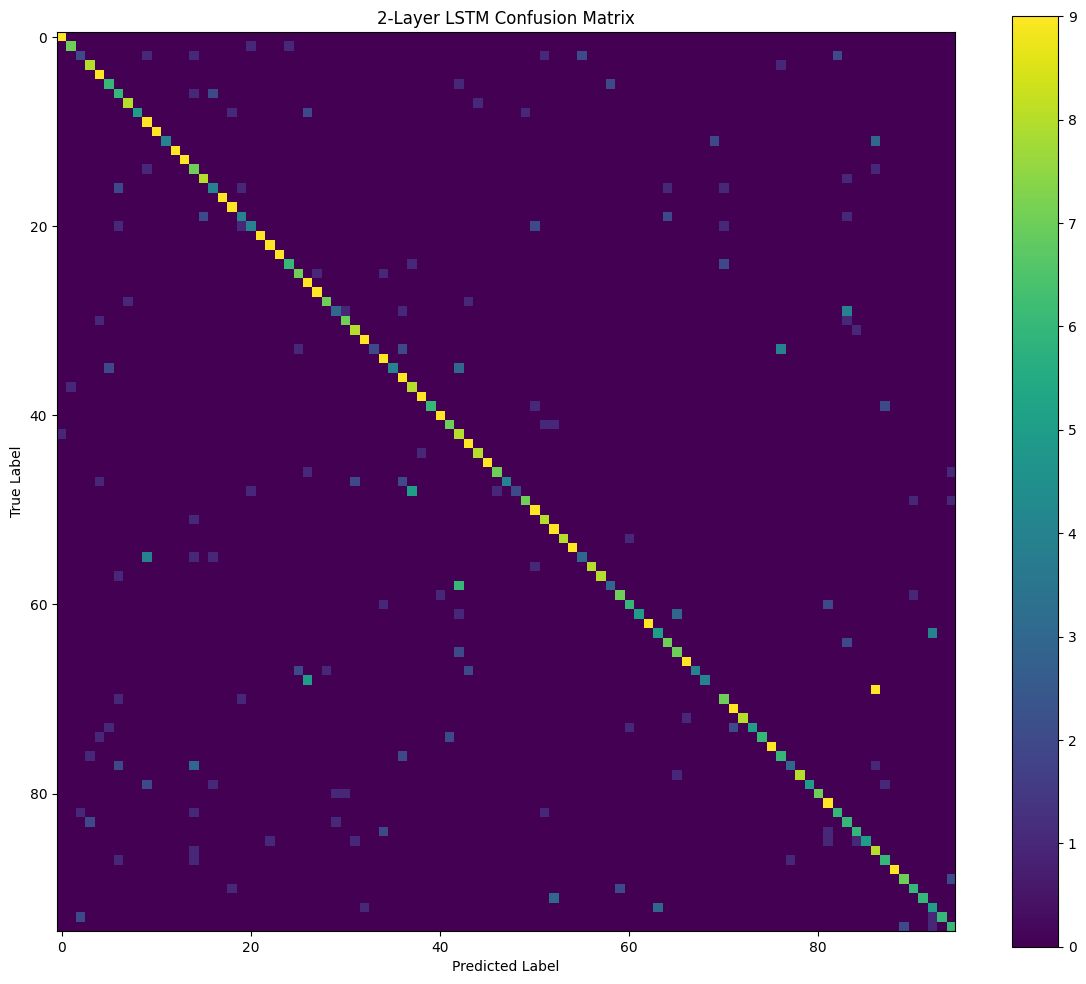

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("2-Layer LSTM Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [14]:
#Build 3 Layer Architecture LSTM

model_3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(57, 22)),

    tf.keras.layers.LSTM(
        128,
        return_sequences=True
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(
        64,
        return_sequences=True
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(
        32
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        95,
        activation="softmax"
    )
])

model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 57, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 57, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 57, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 57, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 95)             │         3,135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,271 (555.75 KB)

 Trainable params: 142,271 (555.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

In [16]:
history = model_3.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.0240 - loss: 4.5194 - val_accuracy: 0.0117 - val_loss: 4.4184
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.0591 - loss: 4.2673 - val_accuracy: 0.0292 - val_loss: 4.1250
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.0682 - loss: 3.9602 - val_accuracy: 0.0234 - val_loss: 3.8619
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.0780 - loss: 3.7174 - val_accuracy: 0.0702 - val_loss: 3.5582
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.0877 - loss: 3.5419 - val_accuracy: 0.0702 - val_loss: 3.5657
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.1228 - loss: 3.3627 - val_accuracy: 0.0936 - val_loss: 3.3488
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.1501 - loss: 3.1865 - val_accuracy: 0.1287 - val_loss: 3.1812
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.1378 - loss: 3.1570 - val_accuracy: 

In [17]:
test_loss, test_accuracy = model_3.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6082 - loss: 1.3203
Test Loss: 1.3203
Test Accuracy: 0.6082


In [18]:
y_prob = model_3.predict(X_test)

y_pred = np.argmax(
    y_prob,
    axis=1
)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step


In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

                precision    recall  f1-score   support

           God     0.5385    0.7778    0.6364         9
             I     0.4615    0.6667    0.5455         9
        Norway     0.6250    0.5556    0.5882         9
         alive     0.2000    0.2222    0.2105         9
           all     1.0000    0.6667    0.8000         9
        answer     0.8571    0.6667    0.7500         9
           boy     0.4615    0.6667    0.5455         9
      building     0.8333    0.5556    0.6667         9
           buy     0.8750    0.7778    0.8235         9
  change_mind_     0.6667    0.8889    0.7619         9
          cold     1.0000    1.0000    1.0000         9
          come     0.5000    0.4444    0.4706         9
  computer_PC_     1.0000    0.1111    0.2000         9
          cost     1.0000    0.8889    0.9412         9
         crazy     0.5000    1.0000    0.6667         9
        danger     0.7500    0.6667    0.7059         9
          deaf     0.6667    0.2222    0.3333  

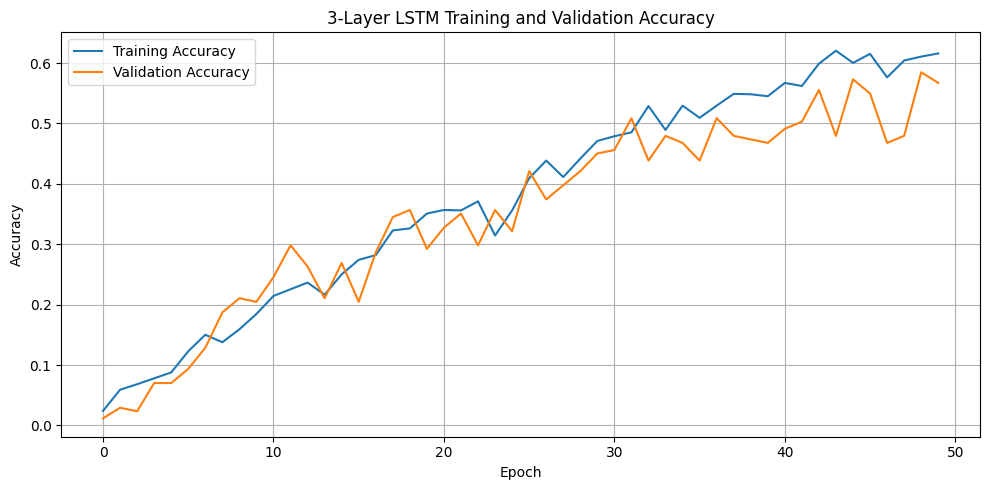

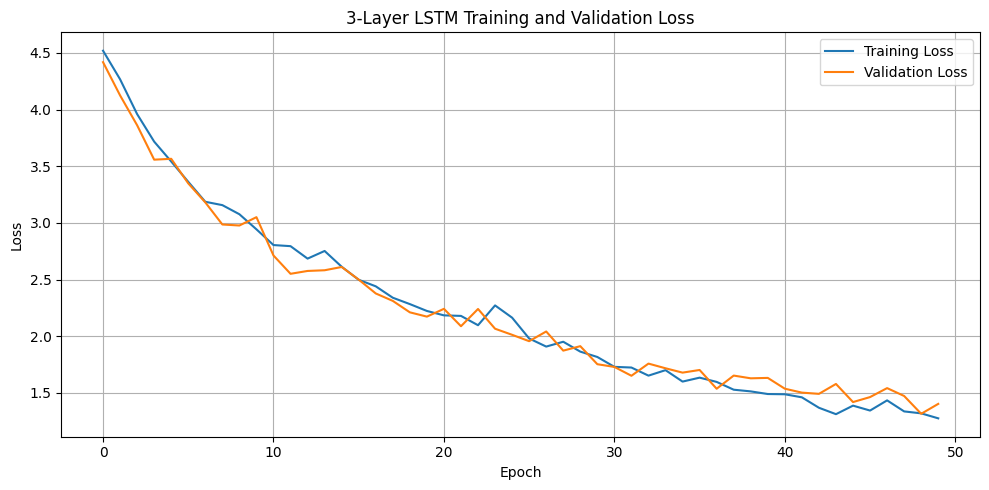

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("3-Layer LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("3-Layer LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

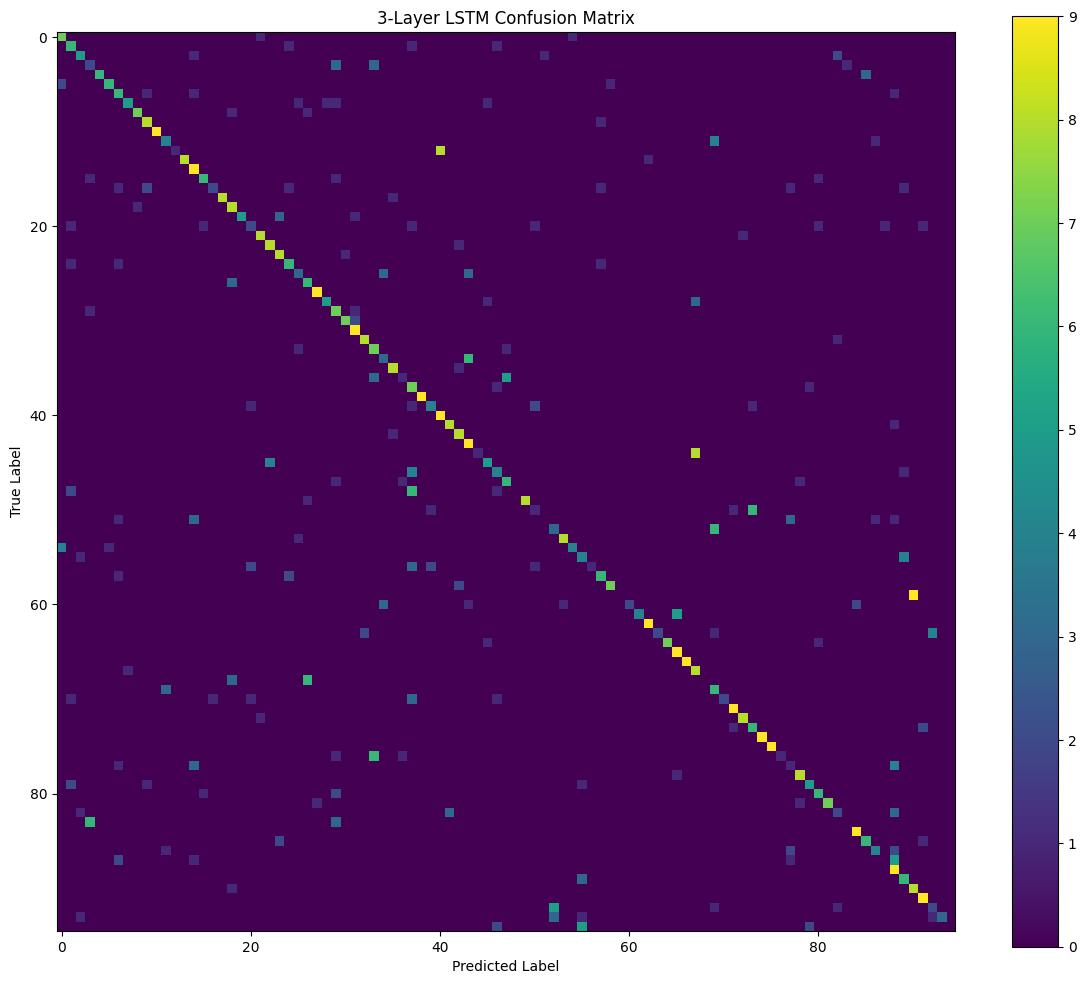

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("3-Layer LSTM Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [22]:
report = classification_report(
    y_test,
    y_pred,
    zero_division=0,
    output_dict=True
)

print(f"Accuracy:         {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro Precision:  {report['macro avg']['precision']:.4f}")
print(f"Macro Recall:     {report['macro avg']['recall']:.4f}")
print(f"Macro F1:         {report['macro avg']['f1-score']:.4f}")

Accuracy:         0.6082
Macro Precision:  0.6300
Macro Recall:     0.6082
Macro F1:         0.5742


In [23]:
#3 Layer LSTM seems to never predict some classes at all, check which classes it doesn't predict
import numpy as np
from collections import Counter

prediction_counts = Counter(y_pred)

print("Prediction counts:")
print(sorted(prediction_counts.items()))

unique_predicted = np.unique(y_pred)

print("Number of classes predicted:", len(unique_predicted))
print("Classes never predicted:", 95 - len(unique_predicted))

missing_classes = sorted(
    set(range(95)) - set(unique_predicted)
)

print("Classes never predicted:")
for class_idx in missing_classes:
    sign_name = label_mapping.loc[
        label_mapping["class_id"] == class_idx, "sign"
    ].iloc[0]

    print(f"{class_idx}: {sign_name}")

Prediction counts:
[(np.int64(0), 13), (np.int64(1), 13), (np.int64(2), 8), (np.int64(3), 10), (np.int64(4), 6), (np.int64(5), 7), (np.int64(6), 13), (np.int64(7), 6), (np.int64(8), 8), (np.int64(9), 12), (np.int64(10), 9), (np.int64(11), 8), (np.int64(12), 1), (np.int64(13), 8), (np.int64(14), 18), (np.int64(15), 8), (np.int64(16), 3), (np.int64(17), 8), (np.int64(18), 16), (np.int64(19), 5), (np.int64(20), 6), (np.int64(21), 10), (np.int64(22), 12), (np.int64(23), 13), (np.int64(24), 10), (np.int64(25), 6), (np.int64(26), 14), (np.int64(27), 10), (np.int64(28), 6), (np.int64(29), 19), (np.int64(30), 8), (np.int64(31), 13), (np.int64(32), 10), (np.int64(33), 19), (np.int64(34), 9), (np.int64(35), 10), (np.int64(36), 3), (np.int64(37), 26), (np.int64(38), 9), (np.int64(39), 7), (np.int64(40), 17), (np.int64(41), 11), (np.int64(42), 12), (np.int64(43), 19), (np.int64(44), 1), (np.int64(45), 8), (np.int64(46), 10), (np.int64(47), 12), (np.int64(49), 8), (np.int64(50), 5), (np.int64(51), 